###Exploratory Data Analysis

In [89]:
import pandas as pd
df=pd.read_csv(r'C:\Users\Shiva yadav\Downloads\Titanic-Dataset.csv')

In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
df.shape

(891, 12)

In [30]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [27]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##DATA CLEANING

In [31]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [92]:
df=df.drop('Cabin',axis=1)

In [94]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [96]:
df['Age'].skew()

np.float64(0.38910778230082704)

In [98]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [99]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [101]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [102]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [104]:
print(df.duplicated().sum())

0


##OUTLIERS ANALYSIS

In [107]:
import numpy as np
df.select_dtypes(include=np.number)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.000000,1,0,7.2500
1,2,1,1,38.000000,1,0,71.2833
2,3,1,3,26.000000,0,0,7.9250
3,4,1,1,35.000000,1,0,53.1000
4,5,0,3,35.000000,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000
887,888,1,1,19.000000,0,0,30.0000
888,889,0,3,2969.911765,1,2,23.4500
889,890,1,1,26.000000,0,0,30.0000


In [110]:
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)
    IQR=q3-q1
    UW=q3+1.5*IQR
    LW=q1-1.5*IQR
    Outliers=((a[i]>UW)|(a[i]<LW))
    print (Outliers.sum())
    a.loc[Outliers,i]=q2
    print(f'after removing outliers in {i}:-',((a[i]>UW)|(a[i]<LW)).sum())

0
after removing outliers in PassengerId:- 0
0
after removing outliers in Survived:- 0
0
after removing outliers in Pclass:- 0
94
after removing outliers in Age:- 0
0
after removing outliers in SibSp:- 0
0
after removing outliers in Parch:- 0
34
after removing outliers in Fare:- 0


##DATA ANALYSIS

In [113]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [115]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

##BINNING PROCESS

In [120]:
bins=[0,18,40,70]
labels=['child','adult','old']
df['Agegroup']=pd.cut(df['Age'],bins=bins,labels=labels)

In [125]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Agegroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult


In [145]:
a=df.groupby('Agegroup')['Survived'].mean()*100

In [140]:
b=df.groupby('Sex')['Survived'].mean()*100

In [141]:
c=df.groupby('Pclass')['Survived'].mean()*100

In [142]:
d=df.groupby('Pclass')['PassengerId'].count()

In [143]:
e=df.sort_values(by='Fare',ascending=False)

In [170]:
f=df.groupby('Pclass')['Agegroup'].count()

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

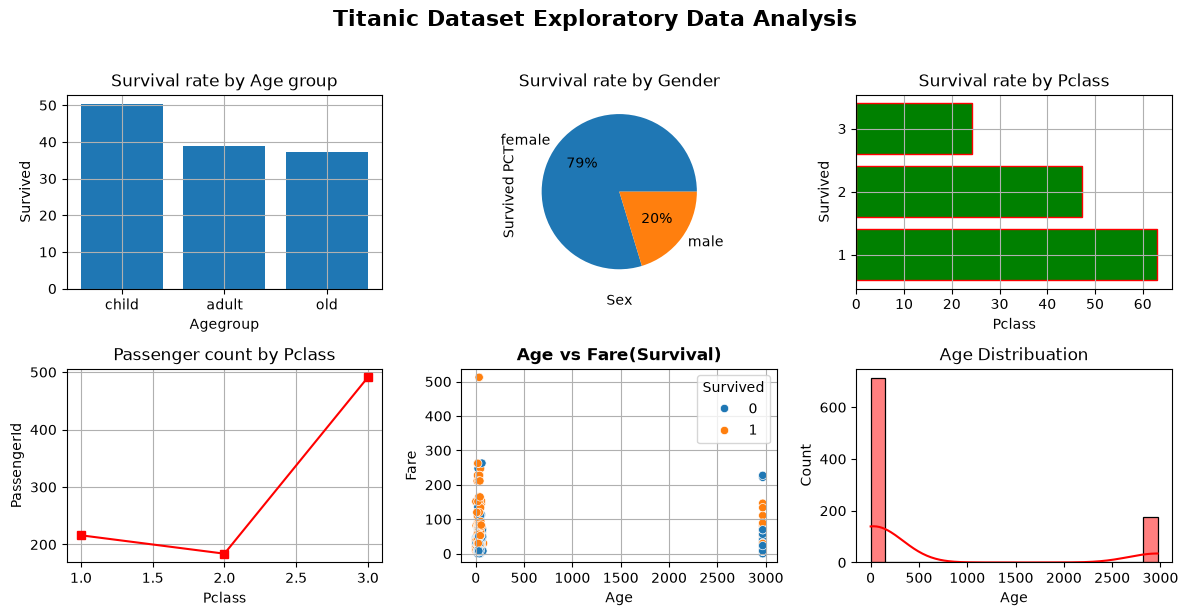

In [194]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plt.bar(a.index,a.values)
plt.grid(True)
plt.xlabel('Agegroup')
plt.ylabel('Survived')
plt.title('Survival rate by Age group')
plt.subplot(2,3,2)
plt.pie(b.values,labels=b.index,autopct='%1d%%')
plt.xlabel('Sex')
plt.ylabel('Survived PCT')
plt.title('Survival rate by Gender')
plt.subplot(2,3,3)
plt.barh(c.index,c.values,color='green',edgecolor='red')
plt.grid(True)
plt.xlabel('Pclass')
plt.ylabel('Survived')
plt.title('Survival rate by Pclass')
plt.subplot(2,3,4)
plt.plot(d.index,d.values,marker='s',color='red')
plt.grid(True)
plt.xlabel('Pclass')
plt.ylabel('PassengerId')
plt.title('Passenger count by Pclass')
plt.subplot(2,3,5)
sns.scatterplot(x='Age',y='Fare',hue='Survived',data=df)
plt.grid(True)
plt.title('Age vs Fare(Survival)',fontsize=12,fontweight='bold')
plt.subplot(2,3,6)
sns.histplot(df['Age'].dropna(),color='Red',kde='True',bins=20)
plt.title('Age Distribuation')
plt.xlabel('Age')
plt.ylabel('Count')
plt.suptitle('Titanic Dataset Exploratory Data Analysis',fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()